# Phase 6, Milestone 1: exact first-passage laws for the bounded correlation coordinate

This notebook is the reproducible computational record for
`PHASE_6_MILESTONE_1_FIRST_PASSAGE.md`. It verifies, by Monte Carlo,
the exact closed-form laws of the bounded correlation coordinate

\[
\rho_t=\sin\theta_t=\frac{X_t}{\sqrt{X_t^2+c^2}},\qquad
X_t=x_0+\mu t+\sigma W_t ,
\]

where \(\theta_t=\arctan(X_t/c)\) is the Phase 5 one-phase Euler
coordinate:

1. the exact finite-time transition density of \(\rho_t\);
2. the first-passage CDF and density of \(\rho_t\) to an upper
   correlation level (reflection principle through the conjugate map);
3. the perpetual hitting probability in the defective (\(\mu<0\)) case;
4. the two-sided band-exit probability from the scale function.

Numerical evidence illustrates and stress-tests the derivations in the
accompanying Markdown document. It does not replace those derivations.

## 1. Environment, reproducibility, and methodology

All paths are sampled as **exact Gaussian skeletons** — no
Euler–Maruyama bias. Intra-step barrier crossings are resolved with
the Brownian-bridge crossing probability, which is drift-free
(conditioning a drifted Brownian motion on its endpoints removes the
drift). Crossing times are recorded at step midpoints; results are
reported at two step sizes with Monte Carlo standard errors.

In [1]:
from pathlib import Path
import json
import platform
import sys
import time

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import scipy
from scipy.integrate import quad
from scipy.stats import norm

ROOT = Path.cwd().resolve()
if not (ROOT / "phase6_correlation.py").exists():
    candidates = [ROOT, *ROOT.parents]
    ROOT = next(path for path in candidates if (path / "phase6_correlation.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import phase6_correlation as p6

SEED = 20260727
rng = np.random.default_rng(SEED)

FIGURES = ROOT / "phase6_figures"
FIGURES.mkdir(exist_ok=True)

environment = {
    "python": platform.python_version(),
    "numpy": np.__version__,
    "scipy": scipy.__version__,
    "matplotlib": matplotlib.__version__,
    "platform": platform.platform(),
    "seed": SEED,
}
print(json.dumps(environment, indent=2))
started = time.time()

{
  "python": "3.12.13",
  "numpy": "2.5.1",
  "scipy": "1.18.0",
  "matplotlib": "3.11.1",
  "platform": "Linux-7.1.4-1-cachyos-x86_64-with-glibc2.43",
  "seed": 20260727
}


## 2. Model and parameters

Two regimes are checked: a **positive-trend** case (\(\mu>0\), every
level is reached eventually) and a **defective** case (\(\mu<0\), each
upper level has a positive probability of never being reached).

In [2]:
SCALE = 1.0
X0 = 0.0
SIGMA = 0.8
MU_POS = 0.3
MU_NEG = -0.5
RHO_STAR = 0.6

rho0 = p6.rho_from_x(X0, scale=SCALE)
x_star = p6.x_from_rho(RHO_STAR, scale=SCALE)
distance = x_star - X0
print(f"rho0            = {rho0:.6f}")
print(f"x*(rho*={RHO_STAR}) = {x_star:.6f}")
print(f"conjugate distance b = {distance:.6f}")

rho0            = 0.000000
x*(rho*=0.6) = 0.750000
conjugate distance b = 0.750000


## 3. Exact finite-time transition density vs. exact-skeleton Monte Carlo

\(X_T\) is sampled exactly as a Gaussian; \(\rho_T=X_T/\sqrt{X_T^2+c^2}\)
inherits the exact law. The overlay compares the Monte Carlo histogram
with the closed-form density, and the mean \(E[\rho_T]\) is compared
against quadrature with its Monte Carlo standard error.

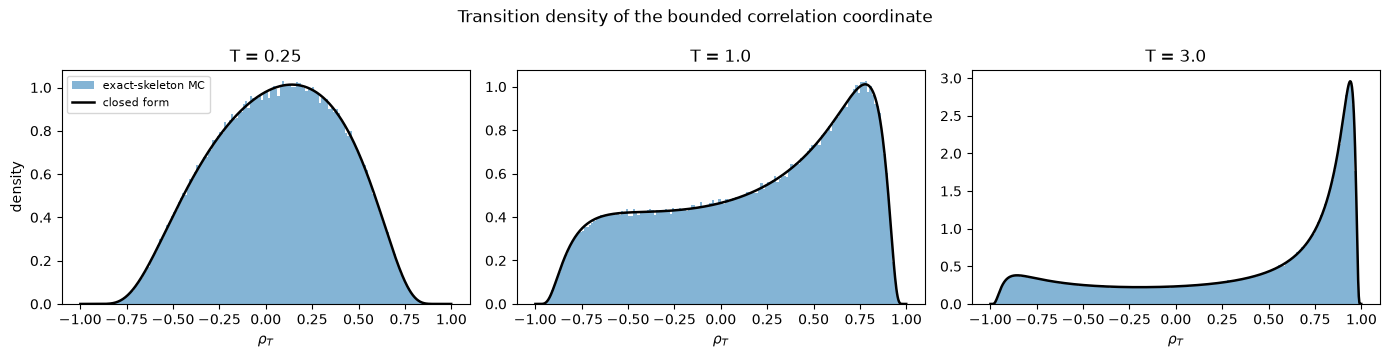

     T  E[rho] quadrature    MC mean     MC SE  z-score
  0.25         0.06290276   0.062201  5.33e-04    -1.32
  1.00         0.18979021   0.190515  8.07e-04     0.90
  3.00         0.39085679   0.392672  9.44e-04     1.92


In [3]:
N_PATHS = 400_000
maturities = (0.25, 1.0, 3.0)
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6), sharey=False)
density_rows = []
for axis, maturity in zip(axes, maturities):
    x_terminal = X0 + MU_POS * maturity + SIGMA * np.sqrt(maturity) * rng.standard_normal(N_PATHS)
    rho_terminal = x_terminal / np.sqrt(x_terminal**2 + SCALE**2)
    grid = np.linspace(-0.999, 0.999, 601)
    exact = np.array([
        p6.rho_transition_density(
            r, maturity=maturity, rho0=rho0,
            drift=MU_POS, volatility=SIGMA, scale=SCALE,
        )
        for r in grid
    ])
    axis.hist(rho_terminal, bins=160, range=(-1, 1), density=True,
              alpha=0.55, label="exact-skeleton MC")
    axis.plot(grid, exact, "k-", lw=1.8, label="closed form")
    axis.set_title(f"T = {maturity}")
    axis.set_xlabel(r"$\rho_T$")
    mean_quad, _ = quad(
        lambda r: r * p6.rho_transition_density(
            r, maturity=maturity, rho0=rho0,
            drift=MU_POS, volatility=SIGMA, scale=SCALE,
        ),
        -1.0, 1.0, epsabs=1e-12,
    )
    mean_mc = rho_terminal.mean()
    mean_se = rho_terminal.std(ddof=1) / np.sqrt(N_PATHS)
    density_rows.append((maturity, mean_quad, mean_mc, mean_se))
axes[0].set_ylabel("density")
axes[0].legend(fontsize=8)
fig.suptitle("Transition density of the bounded correlation coordinate")
fig.tight_layout()
fig.savefig(FIGURES / "phase6_transition_density.png", dpi=150)
plt.show()

print(f"{'T':>6} {'E[rho] quadrature':>18} {'MC mean':>10} {'MC SE':>9} {'z-score':>8}")
for maturity, mean_quad, mean_mc, mean_se in density_rows:
    z = (mean_mc - mean_quad) / mean_se
    print(f"{maturity:6.2f} {mean_quad:18.8f} {mean_mc:10.6f} {mean_se:9.2e} {z:8.2f}")

## 4. First-passage CDF: reflection principle vs. bridge-corrected Monte Carlo

The estimator simulates drifted-Brownian skeletons and, at each step
\([t,t+\Delta t]\) with both endpoints below the barrier, applies the
bridge crossing probability
\(\exp\!\big(-2(b-X_t)(b-X_{t+\Delta t})/(\sigma^2\Delta t)\big)\).

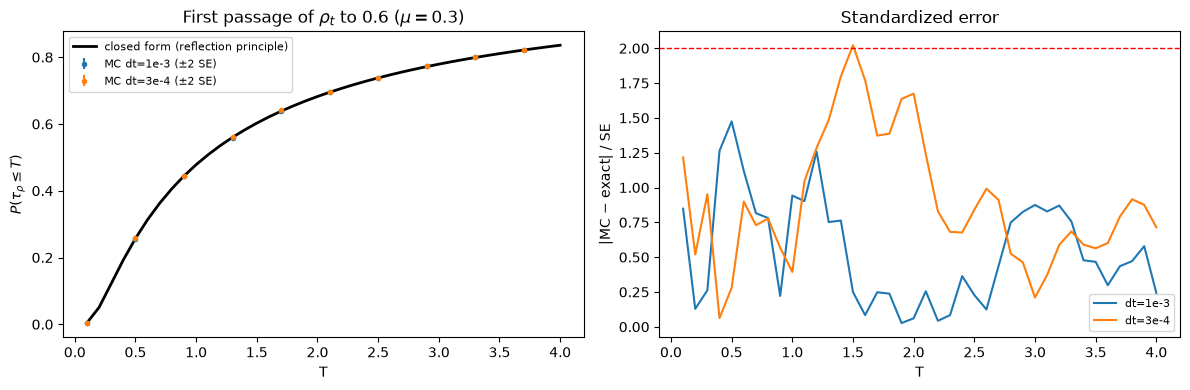

dt=1e-3: max |MC - exact| = 0.0020  (typical SE 0.0014)
dt=3e-4: max |MC - exact| = 0.0031  (typical SE 0.0014)


In [4]:
def simulate_hitting_times(mu, n_paths, horizon, step, seed):
    # Return estimated hitting times (NaN = not hit) for the level x_star.
    # Only alive paths are carried forward: state shrinks as paths cross.
    local_rng = np.random.default_rng(seed)
    n_steps = int(round(horizon / step))
    state = np.full(n_paths, X0)
    alive_idx = np.arange(n_paths)
    hit_time = np.full(n_paths, np.nan)
    sd = SIGMA * np.sqrt(step)
    for k in range(n_steps):
        if state.size == 0:
            break
        old = state
        new = old + mu * step + sd * local_rng.standard_normal(old.size)
        gap_start = x_star - old
        gap_end = x_star - new
        crossed = gap_end <= 0.0
        both_below = (gap_start > 0.0) & (gap_end > 0.0)
        bridge_prob = np.zeros(old.size)
        bridge_prob[both_below] = np.exp(
            -2.0 * gap_start[both_below] * gap_end[both_below] / (SIGMA**2 * step)
        )
        crossed |= local_rng.random(old.size) < bridge_prob
        hit_time[alive_idx[crossed]] = (k + 0.5) * step
        alive_idx = alive_idx[~crossed]
        state = new[~crossed]
    return hit_time

HORIZON = 4.0
N_HIT = 100_000
grid_T = np.linspace(0.1, HORIZON, 40)
results = {}
for label, step in (("dt=1e-3", 1e-3), ("dt=3e-4", 3e-4)):
    hits = simulate_hitting_times(MU_POS, N_HIT, HORIZON, step, SEED)
    mc_cdf = np.array([np.mean(hits <= T) for T in grid_T])
    mc_se = np.sqrt(mc_cdf * (1.0 - mc_cdf) / N_HIT)
    results[label] = (hits, mc_cdf, mc_se)

exact_cdf = np.array([
    p6.brownian_hitting_cdf(T, distance=distance, drift=MU_POS, volatility=SIGMA)
    for T in grid_T
])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(grid_T, exact_cdf, "k-", lw=2, label="closed form (reflection principle)")
for label, (_, mc_cdf, mc_se) in results.items():
    axes[0].errorbar(grid_T[::4], mc_cdf[::4], yerr=2 * mc_se[::4],
                     fmt="o", ms=3, label=f"MC {label} (±2 SE)")
axes[0].set_xlabel("T"); axes[0].set_ylabel(r"$P(\tau_\rho \leq T)$")
axes[0].set_title(rf"First passage of $\rho_t$ to {RHO_STAR} ($\mu={MU_POS}$)")
axes[0].legend(fontsize=8)
for label, (_, mc_cdf, mc_se) in results.items():
    z = np.abs(mc_cdf - exact_cdf) / np.maximum(mc_se, 1e-12)
    axes[1].plot(grid_T, z, label=label)
axes[1].axhline(2.0, color="r", ls="--", lw=1)
axes[1].set_xlabel("T"); axes[1].set_ylabel("|MC − exact| / SE")
axes[1].set_title("Standardized error")
axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "phase6_hitting_cdf.png", dpi=150)
plt.show()

for label, (_, mc_cdf, mc_se) in results.items():
    max_abs = np.max(np.abs(mc_cdf - exact_cdf))
    print(f"{label}: max |MC - exact| = {max_abs:.4f}  (typical SE {np.median(mc_se):.4f})")

## 5. Hitting-time density: inverse Gaussian vs. Monte Carlo

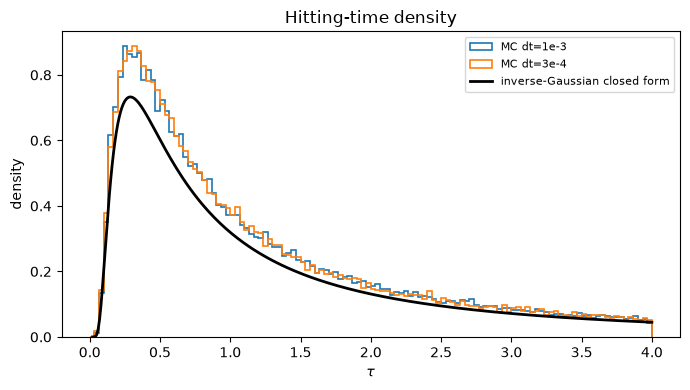

In [5]:
density_grid = np.linspace(0.02, HORIZON, 400)
exact_density = np.array([
    p6.brownian_hitting_density(t, distance=distance, drift=MU_POS, volatility=SIGMA)
    for t in density_grid
])
fig, ax = plt.subplots(figsize=(7, 4))
for label, (hits, _, _) in results.items():
    ax.hist(hits[np.isfinite(hits)], bins=120, range=(0, HORIZON),
            density=True, histtype="step", lw=1.2, label=f"MC {label}")
ax.plot(density_grid, exact_density, "k-", lw=2, label="inverse-Gaussian closed form")
ax.set_xlabel(r"$\tau$"); ax.set_ylabel("density")
ax.set_title("Hitting-time density")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "phase6_hitting_density.png", dpi=150)
plt.show()

## 6. Defective case (\(\mu<0\)): perpetual hitting probability

With \(\mu<0\) the closed form predicts
\(P(\tau<\infty)=e^{2\mu b/\sigma^2}<1\). The Monte Carlo estimator
uses the finite-horizon CDF at \(T=20\), where the remaining tail mass
is negligible on the scale of the Monte Carlo standard error.

In [6]:
N_DEF = 100_000
hits_neg = simulate_hitting_times(MU_NEG, N_DEF, 20.0, 2e-3, SEED)
mc_perpetual = np.mean(np.isfinite(hits_neg))
mc_perpetual_se = np.sqrt(mc_perpetual * (1 - mc_perpetual) / N_DEF)
exact_perpetual = p6.perpetual_hitting_probability(
    distance=distance, drift=MU_NEG, volatility=SIGMA
)
cdf_tail = p6.brownian_hitting_cdf(20.0, distance=distance, drift=MU_NEG, volatility=SIGMA)
print(f"exact perpetual P(tau<inf) = {exact_perpetual:.6f}")
print(f"closed-form CDF at T=20    = {cdf_tail:.6f}")
print(f"MC estimate (T=20)         = {mc_perpetual:.6f} ± {2*mc_perpetual_se:.6f} (2 SE)")
z = (mc_perpetual - cdf_tail) / mc_perpetual_se
print(f"standardized difference vs CDF(20): {z:.2f}")

exact perpetual P(tau<inf) = 0.309786
closed-form CDF at T=20    = 0.309608
MC estimate (T=20)         = 0.309550 ± 0.002924 (2 SE)
standardized difference vs CDF(20): -0.04


## 7. Two-sided correlation band exit: scale function vs. Monte Carlo

For a band \((\rho_\ell,\rho_h)\) the probability of exiting at the top
is the scale-function ratio. The check sweeps the starting correlation
\(\rho_0\) (equivalently \(x_0\)) with fixed barriers.

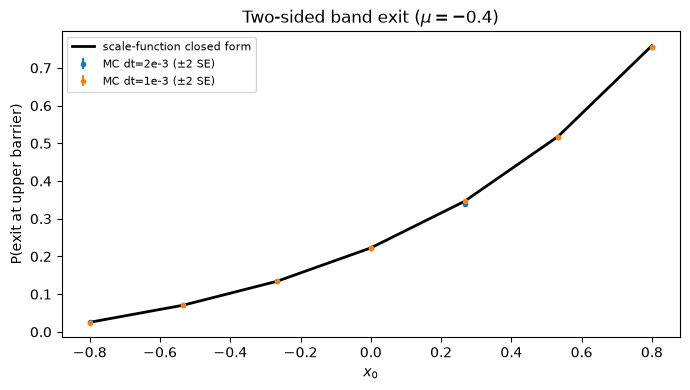

max |MC - exact| over starts (fine grid): 0.00315


In [7]:
def simulate_exit_side(mu, x_start, x_lower, x_upper, n_paths, step, seed):
    # Return (exited_upper mask, still-alive mask); only alive paths are
    # carried forward. Horizon 20 is ample for a two-barrier exit.
    local_rng = np.random.default_rng(seed)
    state = np.full(n_paths, float(x_start))
    alive_idx = np.arange(n_paths)
    exited_upper = np.zeros(n_paths, dtype=bool)
    alive = np.ones(n_paths, dtype=bool)
    sd = SIGMA * np.sqrt(step)
    max_steps = int(round(20.0 / step))
    for _ in range(max_steps):
        if state.size == 0:
            break
        old = state
        new = old + mu * step + sd * local_rng.standard_normal(old.size)
        up = new >= x_upper
        down = new <= x_lower
        inside = ~(up | down)
        # Bridge corrections for paths staying inside the skeleton band.
        p_up = np.exp(-2.0 * (x_upper - old[inside]) * (x_upper - new[inside]) / (SIGMA**2 * step))
        p_down = np.exp(-2.0 * (old[inside] - x_lower) * (new[inside] - x_lower) / (SIGMA**2 * step))
        draws = local_rng.random(inside.sum())
        idx_inside = np.flatnonzero(inside)
        up_bridge = draws < p_up / np.maximum(1.0 - p_down, 1e-12)
        down_bridge = ~up_bridge & (draws < p_down)
        up[idx_inside[up_bridge]] = True
        down[idx_inside[down_bridge]] = True
        exited_upper[alive_idx[up]] = True
        alive[alive_idx[up | down]] = False
        alive_idx = alive_idx[~(up | down)]
        state = new[~(up | down)]
    return exited_upper, alive

X_LOWER, X_UPPER = -1.0, 1.0
MU_EXIT = -0.4
starts = np.linspace(-0.8, 0.8, 7)
fig, ax = plt.subplots(figsize=(7, 4))
for label, step in (("dt=2e-3", 2e-3), ("dt=1e-3", 1e-3)):
    estimates, ses = [], []
    for x_start in starts:
        exited_upper, alive = simulate_exit_side(
            MU_EXIT, x_start, X_LOWER, X_UPPER, 60_000, step, SEED
        )
        assert not alive.any(), "exit simulation horizon too short"
        p_hat = exited_upper.mean()
        estimates.append(p_hat)
        ses.append(np.sqrt(p_hat * (1 - p_hat) / exited_upper.size))
    ax.errorbar(starts, estimates, yerr=2 * np.array(ses), fmt="o", ms=3, label=f"MC {label} (±2 SE)")
exact_exit = np.array([
    p6.first_exit_probability_upper(
        start=s, lower=X_LOWER, upper=X_UPPER, drift=MU_EXIT, volatility=SIGMA
    )
    for s in starts
])
ax.plot(starts, exact_exit, "k-", lw=2, label="scale-function closed form")
ax.set_xlabel(r"$x_0$"); ax.set_ylabel("P(exit at upper barrier)")
ax.set_title(rf"Two-sided band exit ($\mu={MU_EXIT}$)")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "phase6_exit_probability.png", dpi=150)
plt.show()

max_dev = np.max(np.abs(np.array(estimates) - exact_exit))
print(f"max |MC - exact| over starts (fine grid): {max_dev:.5f}")

## 8. Runtime and reproducibility record

In [8]:
print(f"total runtime: {time.time() - started:.1f} s")
print(json.dumps(environment, indent=2))

total runtime: 44.7 s
{
  "python": "3.12.13",
  "numpy": "2.5.1",
  "scipy": "1.18.0",
  "matplotlib": "3.11.1",
  "platform": "Linux-7.1.4-1-cachyos-x86_64-with-glibc2.43",
  "seed": 20260727
}
